# ECO225: Data Tools for Economists
## Practical 5 - APIs & Relational Databases

**Instructor:** Professor Nicholas Zammit  
**Tutorial Leader:** Saurabh Nair  
**Date:** February 10, 2026

---

### Learning Objectives

- Fetch economic data from APIs (FRED)
- Parse JSON responses
- Create SQLite databases
- Write SQL queries (SELECT, JOIN, GROUP BY)
- Combine API data with database queries
- Perform integrated economic analysis

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sqlite3
import json

np.random.seed(42)
print("Libraries imported!")

Libraries imported!


## Part 1: Introduction to APIs

**API (Application Programming Interface):** Allows programs to request data from services.

**Why use APIs?**
- Always up-to-date data
- Automated data collection
- No manual downloads

**Popular Economic APIs:**
- FRED (Federal Reserve)
- World Bank
- IMF
- BLS

### Simple API Example

In [2]:
#APIs more up to date, dont have to manually do anything
# Example: Exchange rates
url = "https://api.exchangerate-api.com/v4/latest/USD"
response = requests.get(url)

print(f"Status: {response.status_code}")  # 200 = success
#3 digit success codes 

data = response.json()
print(f"\nUSD to CAD: {data['rates']['CAD']:.4f}")
print(f"USD to EUR: {data['rates']['EUR']:.4f}")

Status: 200

USD to CAD: 1.3700
USD to EUR: 0.8700


## Part 2: FRED API

Get your free API key: https://fred.stlouisfed.org/

In [3]:
# Setup FRED API key
FRED_API_KEY = "457629ebff6d23f5a840a64d35ef3f41"  # Replace with your key

# Common series:
# UNRATE - Unemployment Rate
# CPIAUCSL - CPI
# GDP - GDP
# FEDFUNDS - Fed Funds Rate

In [4]:
def fetch_fred_series(series_id, api_key):
    """
    Fetch data from FRED API.
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        
        data = response.json()
        observations = data.get('observations', [])
        
        df = pd.DataFrame(observations)
        df = df[['date', 'value']]
        df['date'] = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df = df.dropna()
        df = df.set_index('date')
        df.columns = [series_id]
        
        return df
    except Exception as e:
        print(f"Error: {e}")
        return pd.DataFrame()

print("Function ready!")

Function ready!


In [5]:
# Fetch unemployment data
unemployment = fetch_fred_series("UNRATE", FRED_API_KEY)

if not unemployment.empty:
    print("Unemployment Rate:")
    print(unemployment.tail())
    print(f"\nMean: {unemployment['UNRATE'].mean():.2f}%")

Unemployment Rate:
            UNRATE
date              
2025-09-01     4.4
2025-11-01     4.5
2025-12-01     4.4
2026-01-01     4.3
2026-02-01     4.4

Mean: 5.66%


## Part 3: SQL Databases

In [6]:
# Create sample country data
countries_df = pd.DataFrame({
    'country_code': ['USA', 'CAN', 'MEX', 'GBR', 'DEU'],
    'country_name': ['United States', 'Canada', 'Mexico', 'United Kingdom', 'Germany'],
    'region': ['North America', 'North America', 'North America', 'Europe', 'Europe'],
    'population_millions': [331, 38, 128, 67, 84]
})

print(countries_df)

  country_code    country_name         region  population_millions
0          USA   United States  North America                  331
1          CAN          Canada  North America                   38
2          MEX          Mexico  North America                  128
3          GBR  United Kingdom         Europe                   67
4          DEU         Germany         Europe                   84


In [7]:
# Create database
conn = sqlite3.connect('economics.db')

# Write table
countries_df.to_sql('countries', conn, if_exists='replace', index=False)

print("Database created!")

Database created!


### SQL Queries

In [8]:
# Basic SELECT
query = "SELECT * FROM countries"
result = pd.read_sql(query, conn)
print(result)

  country_code    country_name         region  population_millions
0          USA   United States  North America                  331
1          CAN          Canada  North America                   38
2          MEX          Mexico  North America                  128
3          GBR  United Kingdom         Europe                   67
4          DEU         Germany         Europe                   84


In [9]:
# WHERE clause
query = """
SELECT country_name, population_millions 
FROM countries 
WHERE region = 'North America'
"""
result = pd.read_sql(query, conn)
print(result)

    country_name  population_millions
0  United States                  331
1         Canada                   38
2         Mexico                  128


In [10]:
# Create GDP table
gdp_df = pd.DataFrame({
    'country_code': ['USA', 'CAN', 'MEX', 'GBR', 'DEU'] * 3,
    'year': [2020]*5 + [2021]*5 + [2022]*5,
    'gdp_billions': [21000, 1600, 1100, 2800, 3800,
                     21500, 1650, 1150, 2900, 3900,
                     22000, 1700, 1200, 3000, 4000]
})

gdp_df.to_sql('gdp', conn, if_exists='replace', index=False)
print("GDP table created")

GDP table created


In [11]:
# JOIN query
query = """
SELECT c.country_name, c.region, g.year, g.gdp_billions
FROM countries c
INNER JOIN gdp g ON c.country_code = g.country_code
WHERE g.year = 2022
"""
result = pd.read_sql(query, conn)
print(result)

     country_name         region  year  gdp_billions
0   United States  North America  2022         22000
1          Canada  North America  2022          1700
2          Mexico  North America  2022          1200
3  United Kingdom         Europe  2022          3000
4         Germany         Europe  2022          4000


In [12]:
# GROUP BY
query = """
SELECT c.region, AVG(g.gdp_billions) as avg_gdp
FROM countries c
INNER JOIN gdp g ON c.country_code = g.country_code
GROUP BY c.region
"""
result = pd.read_sql(query, conn)
print(result)

          region  avg_gdp
0         Europe   3400.0
1  North America   8100.0


## Part 4: Combining API + Database

In [13]:
# Fetch multiple series from FRED
cpi = fetch_fred_series("CPIAUCSL", FRED_API_KEY)
gdp_us = fetch_fred_series("GDP", FRED_API_KEY)

# Merge API data
fred_data = unemployment.join([cpi, gdp_us], how='outer')
fred_data = fred_data.loc['2010':]

print("FRED data:")
print(fred_data.tail())

FRED data:
            UNRATE  CPIAUCSL        GDP
date                                   
2025-10-01     NaN       NaN  31442.483
2025-11-01     4.5   325.063        NaN
2025-12-01     4.4   326.031        NaN
2026-01-01     4.3   326.588        NaN
2026-02-01     4.4   327.460        NaN


In [14]:
# Query database
db_data = pd.read_sql("SELECT * FROM gdp WHERE country_code = 'USA'", conn)

print("\nDatabase data:")
print(db_data)


Database data:
  country_code  year  gdp_billions
0          USA  2020         21000
1          USA  2021         21500
2          USA  2022         22000


---
## Exercises

### Exercise 1: Fetch API Data (20 points)

Fetch two economic series from FRED.

In [15]:
# TODO: Fetch inflation (CPIAUCSL) and interest rate (FEDFUNDS)
inflation = fetch_fred_series("CPIAUCSL", FRED_API_KEY)
interest_rate = fetch_fred_series("FEDFUNDS", FRED_API_KEY)

# TODO: Merge them
my_data = inflation.join(interest_rate, how='outer')

print(my_data.tail())

            CPIAUCSL  FEDFUNDS
date                          
2025-10-01       NaN      4.09
2025-11-01   325.063      3.88
2025-12-01   326.031      3.72
2026-01-01   326.588      3.64
2026-02-01   327.460      3.64


### Exercise 2: Create Database Tables (25 points)

Create unemployment table and add to database.

In [16]:
# TODO: Create unemployment DataFrame
unemployment_df = pd.DataFrame({
    'country_code': ['USA', 'CAN', 'MEX', 'GBR', 'DEU'] * 3,
    'year': [2020]*5 + [2021]*5 + [2022]*5,
    'unemployment_rate': [8.1, 9.5, 4.7, 4.5, 4.0,
                          5.4, 7.5, 4.1, 4.6, 3.6,
                          3.6, 5.3, 3.3, 3.7, 3.1]
})

# TODO: Write to database
unemployment_df.to_sql('unemployment', conn, if_exists='replace', index=False)

print("Unemployment table created!")
print(unemployment_df)

Unemployment table created!
   country_code  year  unemployment_rate
0           USA  2020                8.1
1           CAN  2020                9.5
2           MEX  2020                4.7
3           GBR  2020                4.5
4           DEU  2020                4.0
5           USA  2021                5.4
6           CAN  2021                7.5
7           MEX  2021                4.1
8           GBR  2021                4.6
9           DEU  2021                3.6
10          USA  2022                3.6
11          CAN  2022                5.3
12          MEX  2022                3.3
13          GBR  2022                3.7
14          DEU  2022                3.1


### Exercise 3: SQL Queries (30 points)

Write SQL queries to analyze the data.

In [17]:
# TODO: Query 1 - Average unemployment by region
query1 = """
SELECT c.region, AVG(u.unemployment_rate) AS avg_unemployment
FROM countries c
INNER JOIN unemployment u
    ON c.country_code = u.country_code
GROUP BY c.region
"""
result1 = pd.read_sql(query1, conn)
print(result1)

          region  avg_unemployment
0         Europe          3.916667
1  North America          5.722222


In [18]:
# TODO: Query 2 - Join gdp and unemployment for 2022
query2 = """
SELECT g.country_code, g.year, g.gdp_billions, u.unemployment_rate
FROM gdp g
INNER JOIN unemployment u
    ON g.country_code = u.country_code
    AND g.year = u.year
WHERE g.year = 2022
"""
result2 = pd.read_sql(query2, conn)
print(result2)

  country_code  year  gdp_billions  unemployment_rate
0          USA  2022         22000                3.6
1          CAN  2022          1700                5.3
2          MEX  2022          1200                3.3
3          GBR  2022          3000                3.7
4          DEU  2022          4000                3.1


In [19]:
# TODO: Query 3 - Calculate Misery Index using SQL
# Assume you have inflation data in a table
inflation_df = pd.DataFrame({
    'country_code': ['USA', 'CAN', 'MEX', 'GBR', 'DEU'] * 3,
    'year': [2020]*5 + [2021]*5 + [2022]*5,
    'inflation_rate': [1.2, 0.7, 3.4, 0.9, 0.5,
                       4.7, 3.4, 5.7, 2.5, 3.1,
                       8.0, 6.8, 7.9, 9.1, 8.7]
})

inflation_df.to_sql('inflation', conn, if_exists='replace', index=False)

query3 = """
SELECT u.country_code, u.year, u.unemployment_rate, i.inflation_rate,
       (u.unemployment_rate + i.inflation_rate) AS misery_index
FROM unemployment u
INNER JOIN inflation i
    ON u.country_code = i.country_code
    AND u.year = i.year
ORDER BY u.year, misery_index DESC
"""
result3 = pd.read_sql(query3, conn)
print(result3)

   country_code  year  unemployment_rate  inflation_rate  misery_index
0           CAN  2020                9.5             0.7          10.2
1           USA  2020                8.1             1.2           9.3
2           MEX  2020                4.7             3.4           8.1
3           GBR  2020                4.5             0.9           5.4
4           DEU  2020                4.0             0.5           4.5
5           CAN  2021                7.5             3.4          10.9
6           USA  2021                5.4             4.7          10.1
7           MEX  2021                4.1             5.7           9.8
8           GBR  2021                4.6             2.5           7.1
9           DEU  2021                3.6             3.1           6.7
10          GBR  2022                3.7             9.1          12.8
11          CAN  2022                5.3             6.8          12.1
12          DEU  2022                3.1             8.7          11.8
13    

### Exercise 4: Integrated Analysis (25 points)

Combine API data with database queries.

US unemployment from API:
            UNRATE
date              
2020-01-01     3.6
2020-02-01     3.5
2020-03-01     4.4
2020-04-01    14.8
2020-05-01    13.2
2020-06-01    11.0
2020-07-01    10.2
2020-08-01     8.4
2020-09-01     7.8
2020-10-01     6.9
2020-11-01     6.7
2020-12-01     6.7
2021-01-01     6.4
2021-02-01     6.2
2021-03-01     6.1
2021-04-01     6.1
2021-05-01     5.8
2021-06-01     5.9
2021-07-01     5.4
2021-08-01     5.1
2021-09-01     4.7
2021-10-01     4.5
2021-11-01     4.1
2021-12-01     3.9
2022-01-01     4.0
2022-02-01     3.9
2022-03-01     3.7
2022-04-01     3.7
2022-05-01     3.6
2022-06-01     3.6
2022-07-01     3.5
2022-08-01     3.6
2022-09-01     3.5
2022-10-01     3.6
2022-11-01     3.6
2022-12-01     3.5

International unemployment from database:
      country_name  year  unemployment_rate
0           Canada  2020                9.5
1          Germany  2020                4.0
2   United Kingdom  2020                4.5
3           Mexico  2020         

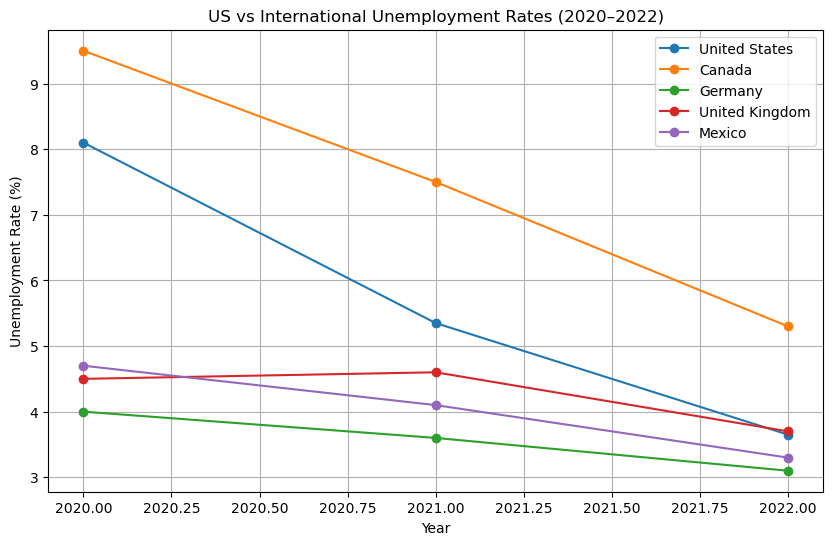

In [21]:
# TODO: Fetch US unemployment from FRED
us_unemployment_api = fetch_fred_series("UNRATE", FRED_API_KEY)
us_unemployment_api = us_unemployment_api.loc['2020':'2022']

# TODO: Query international unemployment from database
intl_unemployment_db = pd.read_sql("""
SELECT c.country_name, u.year, u.unemployment_rate
FROM countries c
INNER JOIN unemployment u
    ON c.country_code = u.country_code
WHERE c.country_code != 'USA'
ORDER BY u.year, c.country_code
""", conn)

print("US unemployment from API:")
print(us_unemployment_api)

print("\nInternational unemployment from database:")
print(intl_unemployment_db)
# TODO: Compare US (API) vs other countries (database)
us_yearly = us_unemployment_api.copy()
us_yearly['year'] = us_yearly.index.year
us_yearly = us_yearly.groupby('year')['UNRATE'].mean().reset_index()
us_yearly['country_name'] = 'United States'
us_yearly = us_yearly.rename(columns={'UNRATE': 'unemployment_rate'})

comparison_df = pd.concat([us_yearly[['country_name', 'year', 'unemployment_rate']],
                           intl_unemployment_db], ignore_index=True)

plt.figure(figsize=(10,6))

for country in comparison_df['country_name'].unique():
    country_data = comparison_df[comparison_df['country_name'] == country]
    plt.plot(country_data['year'], country_data['unemployment_rate'], marker='o', label=country)

plt.title('US vs International Unemployment Rates (2020–2022)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

---
## Summary

In this lab, you learned:
- What APIs are and why they're useful
- Making HTTP requests to retrieve data
- Working with the FRED API for economic data
- Creating SQLite databases in Python
- Writing SQL queries (SELECT, WHERE, JOIN, GROUP BY)
- Joining multiple data sources (API + Database)
- Creating reusable functions for data retrieval

**Key Python libraries:**
- `requests` - make API calls
- `sqlite3` - work with databases
- `.json()` - parse JSON responses
- `pd.read_sql()` - query databases

**Key SQL commands:**
- `SELECT` - retrieve data
- `WHERE` - filter rows
- `JOIN` - combine tables
- `GROUP BY` - aggregate data
- `ORDER BY` - sort results

**Key pandas functions:**
- `.merge()` - combine DataFrames
- `.to_sql()` - write to database
- `pd.read_sql()` - read from database

**Next week:** Web Scraping!

---
### Submission Instructions
1. Complete all TODO sections
2. Obtain FRED API key
3. Complete all SQL queries
4. Answer interpretation questions
5. Ensure all code cells run without errors
6. Push to GitHub repository

**Grading:** This lab is worth 1% of your final grade and will be graded on:
- Completion of all tasks (70%)
- Code correctness (20%)
- Reasonable participation and effort (10%)